# Xgboost + SMOTEENN

In [1]:
# Imports principais
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.pipeline import Pipeline
from imblearn.combine import SMOTEENN

In [2]:
df = pd.read_csv("..\\datasets_paralelos\\kmeans_7clusters.csv")

In [3]:
# 2. Separar X e y
X = df.drop(columns=['cluster'])
Y = df['cluster']

In [4]:
# 3. Divisão treino/teste
X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.3, random_state=42, stratify=Y
)

In [5]:
model = xgb_model = XGBClassifier(
    objective='multi:softprob',   # para multiclasse com probabilidades
    num_class=5,                  # número de classes (clusters)
    eval_metric='mlogloss',       # boa métrica para multiclasse
    use_label_encoder=False,      # evita warning em versões novas

    # Hiperparâmetros iniciais
    n_estimators=200,             # número de árvores (boosting rounds)
    max_depth=6,                  # profundidade máxima de cada árvore
    learning_rate=0.1,            # taxa de aprendizado
    subsample=0.8,                # fração de amostras para cada árvore
    colsample_bytree=0.8,         # fração de features por árvore
    gamma=0,                      # regularização para split
    reg_alpha=0.1,                # L1 regularization
    reg_lambda=1,                 # L2 regularization

    random_state=42,
    verbosity=1
)

In [6]:
pipeline = Pipeline([
    ('smoteenn', SMOTEENN(random_state=42)),  # SMOTE + ENN para balanceamento
    ('clf', model)  # Classificador XGBoost
])

In [7]:
# 5. Cross-validation
cv_scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring='accuracy', n_jobs=-1)
print("Acurácias de cross-validation:", cv_scores)
print("Média da acurácia de cross-validation:", np.mean(cv_scores))

Acurácias de cross-validation: [0.96390938 0.96320688 0.96566561 0.96636811 0.9662803 ]
Média da acurácia de cross-validation: 0.9650860554970144


In [8]:
# 6. Treinar o pipeline completo no treino
pipeline.fit(X_train, y_train)

e:\Faculdade\PISI3\projetodb\PISI3\venv\Lib\site-packages\xgboost\training.py:183: UserWarning: [18:41:45] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Pipeline(steps=[('smoteenn', SMOTEENN(random_state=42)),
                ('clf',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=0.8, device=None,
                               early_stopping_rounds=None,
                               enable_categorical=False, eval_metric='mlogloss',
                               feature_types=None, feature_weights=None,
                               gamma=0, grow_policy=None, importance_type=None,
                               interaction_constraints=None, learning_rate=0.1,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=6, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=200, n_jobs=None, num_class=5, ...))])

In [9]:
# 7. Avaliar no treino
y_train_pred = pipeline.predict(X_train)
print('Métricas de Classificação para o conjunto de treino:')
print(classification_report(y_train, y_train_pred))

Métricas de Classificação para o conjunto de treino:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98     12762
           1       0.97      0.98      0.98     11214
           2       0.96      1.00      0.98      4045
           3       0.98      1.00      0.99      4586
           4       0.96      0.99      0.98      6736
           5       0.98      1.00      0.99       720
           6       0.99      0.96      0.98     16877

    accuracy                           0.98     56940
   macro avg       0.97      0.99      0.98     56940
weighted avg       0.98      0.98      0.98     56940



In [10]:
# 8. Avaliar no teste
y_test_pred = pipeline.predict(X_test)
print("Métricas de Classificação para o conjunto de teste:")
print(classification_report(y_test, y_test_pred))

Métricas de Classificação para o conjunto de teste:
              precision    recall  f1-score   support

           0       0.97      0.97      0.97      5470
           1       0.96      0.97      0.97      4806
           2       0.94      0.99      0.96      1733
           3       0.97      0.99      0.98      1966
           4       0.95      0.99      0.97      2887
           5       0.98      0.99      0.99       308
           6       0.99      0.95      0.97      7233

    accuracy                           0.97     24403
   macro avg       0.96      0.98      0.97     24403
weighted avg       0.97      0.97      0.97     24403



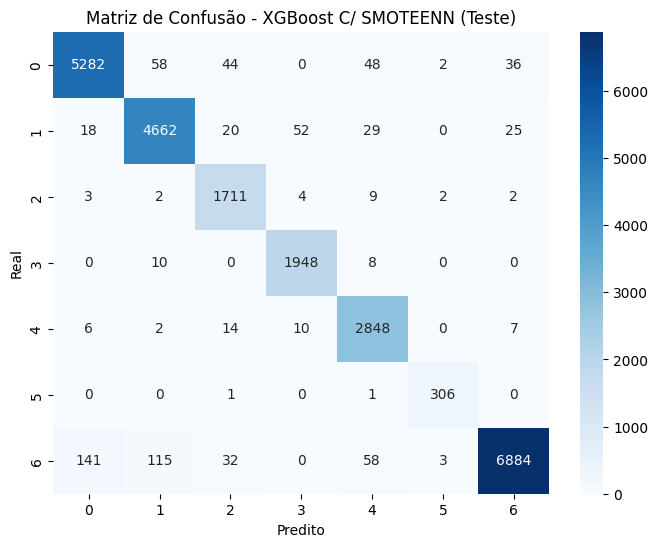

In [11]:
# 9. Matriz de confusão do teste
conf_matrix = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(8,6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', 
            xticklabels=sorted(Y.unique()), yticklabels=sorted(Y.unique()))
plt.xlabel('Predito')
plt.ylabel('Real')
plt.title('Matriz de Confusão - XGBoost C/ SMOTEENN (Teste)')
plt.show()

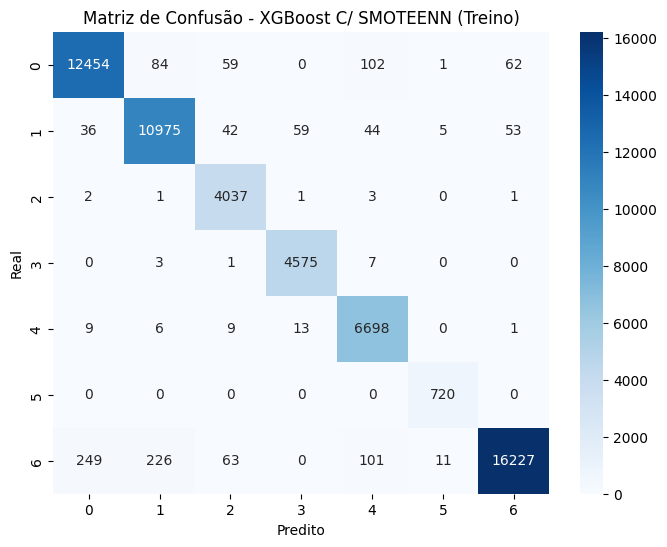

In [12]:

# Matriz de Confusão para o conjunto de treino
conf_matrix = confusion_matrix(y_train, y_train_pred)
plt.figure(figsize=(8,6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', 
            xticklabels=sorted(Y.unique()), yticklabels=sorted(Y.unique()))
plt.xlabel('Predito')
plt.ylabel('Real')
plt.title('Matriz de Confusão - XGBoost C/ SMOTEENN (Treino)')
plt.show()

